# Check data for the spatial transcriptome dataset

Data source: https://cf.10xgenomics.com/samples/spatial-exp/2.0.0/V1_Mouse_Brain_Sagittal_Posterior_Section_2/V1_Mouse_Brain_Sagittal_Posterior_Section_2_web_summary.html 

# 1) Check image and count data

In [5]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import re
import skimage
import skimage.io
import skimage.transform
import tifffile

In [6]:
image_file = "./Sample_data/Dataset_MPB/V1_Mouse_Brain_Sagittal_Posterior_image.tif"
count_file = "./Sample_data/Dataset_MPB/mouse_brain_serial_sagittal_posterior_section1.count.csv"
gene_name = "./Sample_data/Dataset_MPB/mouse_brain_serial_sagittal_posterior_section1.gene_name.csv"
transformation_file = "./Sample_data/Dataset_MPB/mouse_brain_serial_sagittal_posterior_section1.loc.csv"

### X: rows
### Y: columns

(11607, 11620, 3)


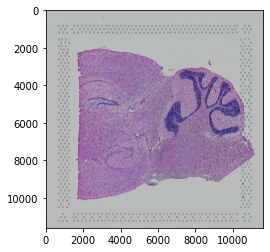

In [12]:
image = tifffile.imread(image_file)
print(image.shape)
plt.imshow(image)
plt.show()
image_norm = image.copy()

### Spot meta file

In [13]:
# Read position meta file
pd_meta = pd.read_table(transformation_file, sep=",")
pd_meta.columns = ['X', 'Y']
pd_meta

,X,Y
0,7409,8455
1,8487,2740
2,3096,7905
3,6570,2052
4,7050,2327
...,...,...
3350,4294,5839
3351,5133,6734
3352,8368,4324
3353,8607,3498


In [14]:
indexes = pd_meta.index.values

In [15]:
# Get image patch
def get_image_patch(image, coords, patch_size):
    """
    Args:
        coords: x, y (col, row) in pixels
    """
    row_start = int(coords[1] - patch_size/2)
    col_start = int(coords[0] - patch_size/2)
    return image[row_start:row_start + patch_size, col_start:col_start + patch_size]

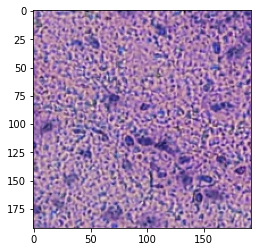

In [16]:
i = -2
x = pd_meta.loc[indexes[i], "Y"]
y = pd_meta.loc[indexes[i], "X"]
PATCH_SIZE = 192
r = int(PATCH_SIZE/2)
plt.imshow(get_image_patch(image_norm, (x, y), PATCH_SIZE))
plt.show()

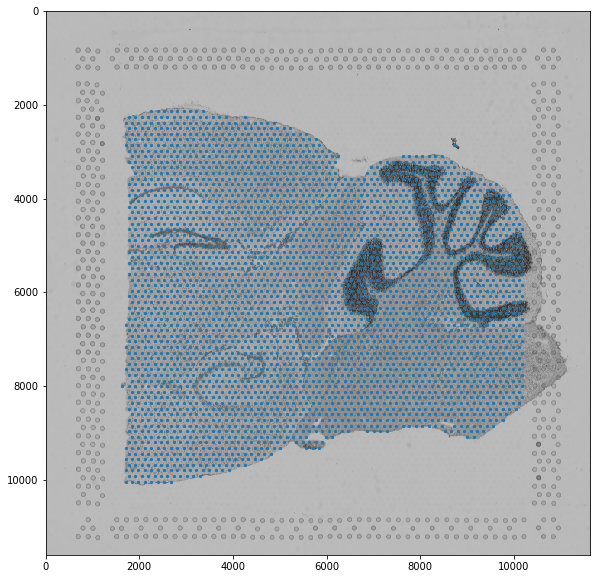

In [17]:
coords_x = pd_meta.loc[:, "Y"].values
coords_y = pd_meta.loc[:, "X"].values
plt.figure(figsize=(10, 10))
plt.imshow(image[..., 0]/255, cmap="gray")
plt.scatter(coords_x, coords_y, s=5)
plt.gca().set_aspect('equal')
plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0)
plt.show()

## Process count file

In [18]:
gene_names = pd.read_csv(gene_name)
gene_names

,x
0,Xkr4
1,Gm1992
2,Gm19938
3,Gm37381
4,Rp1
...,...
32280,AC124606.1
32281,AC133095.2
32282,AC133095.1
32283,AC234645.1


In [19]:
pd_count = pd.read_csv(count_file)
pd_count.columns = gene_names['x'].values
pd_count

,Xkr4,Gm1992,Gm19938,Gm37381,Rp1,Sox17,Gm37587,Gm37323,Mrpl15,Lypla1,...,Gm16367,AC163611.1,AC163611.2,AC140365.1,AC124606.2,AC124606.1,AC133095.2,AC133095.1,AC234645.1,AC149090.1
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,1,2,...,0,0,0,0,0,0,0,0,0,6
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,2
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
3351,0,0,0,0,0,0,0,0,2,2,...,0,0,0,0,0,0,0,0,0,4
3352,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7
3353,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [17]:
## Important
## Sum all isoforms
gene_names = list(set(pd_count.columns.values))
gene_names.sort()
print(len(gene_names))

gene_names_unique = []
gene_names_multiple = []
from tqdm import tqdm
for gene_name in tqdm(gene_names):
    if np.sum(pd_count.columns.values == gene_name) == 1:
        gene_names_unique.append(gene_name)
    else:
        gene_names_multiple.append(gene_name)
print(len(gene_names_unique))
print(len(gene_names_multiple), gene_names_multiple)

32245


100%|██████████| 32245/32245 [00:16<00:00, 1924.18it/s]

32207
38 ['4930594M22Rik', 'Aldoa', 'Arhgef4', 'Btbd35f1', 'C730027H18Rik', 'Ccl19', 'Ccl21a', 'Ccl21b', 'Ccl21c', 'Ccl27a', 'Ddit3', 'Dpep2', 'Fam205a4', 'Fam220a', 'Fam90a1b', 'Gm16364', 'Gm16499', 'Gm16701', 'Gm28710', 'Gm3286', 'Gm35438', 'Gm35558', 'Gm38619', 'Gm41392', 'Gm5089', 'Ighv1-13', 'Ighv5-8', 'Il11ra2', 'Jakmip1', 'Nnt', 'Olfr290', 'Pakap', 'Pcdha11', 'Ptp4a1', 'Sept2', 'Snhg4', 'St6galnac2', 'Zc3h11a']


In [19]:
column_ids = []
for gene_name in tqdm(gene_names):
    column_ids.append(np.argmax(pd_count.columns.values == gene_name))

100%|██████████| 32245/32245 [00:15<00:00, 2067.98it/s]


In [20]:
pd_count_temp = pd_count.iloc[:, column_ids]
for gene_name in gene_names_multiple:
    pd_count_temp.loc[:, gene_name] = np.sum(pd_count.loc[:, gene_name], axis=1)
pd_count = pd_count_temp

/home2/swan15/.conda/envs/mask_rcnn_2/lib/python3.6/site-packages/pandas/core/indexing.py:1046: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item_labels[indexer[info_axis]]] = value


In [ ]:
### End of sum all isoforms

In [26]:
print("Original count size: {}".format(np.shape(pd_count)))

# Remove all 0s genes
gene_sum = np.sum(pd_count, axis=0)
gene_names = gene_sum.index.values[gene_sum > 0]
pd_count_norm = pd_count.loc[:, gene_names]
_pd_count_norm = pd.DataFrame(columns=gene_names, index=pd_count_norm.index.values)

# CPM normalization
from tqdm import tqdm
for n_row in tqdm(range(len(pd_count_norm))):
    # I do not understand why this code does not work
    # pd_count_norm.iloc[n_row, :] = pd_count_norm.iloc[n_row, :] / np.sum(pd_count_norm.iloc[n_row, :]) * 1000000
    _pd_count_norm.iloc[n_row, :] = pd_count_norm.iloc[n_row, :] / np.sum(pd_count_norm.iloc[n_row, :]) * 1000000
pd_count_norm = _pd_count_norm

Original count size: (3355, 32245)


100%|██████████| 3355/3355 [00:32<00:00, 102.14it/s]


In [27]:
np.shape(pd_count_norm)

(3355, 21353)

In [28]:
pd_count_norm

,0610005C13Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610010F05Rik,0610010K14Rik,0610012G03Rik,0610025J13Rik,0610030E20Rik,0610033M10Rik,...,mt-Co2,mt-Co3,mt-Cytb,mt-Nd1,mt-Nd2,mt-Nd3,mt-Nd4,mt-Nd4l,mt-Nd5,mt-Nd6
0,0,108.755,0,0,0,0,0,0,108.755,0,...,17400.8,24034.8,11419.2,6416.53,6307.78,2392.6,8156.61,108.755,870.038,0
1,0,0,0,29.7133,0,59.4265,89.1398,0,0,0,...,15807.5,19135.3,9894.52,6358.64,6744.91,2793.05,7160.9,118.853,831.971,0
2,0,50.971,0,50.971,0,50.971,101.942,0,0,0,...,16463.6,22376.3,14424.8,7441.77,8359.24,2497.58,13405.4,407.768,1478.16,50.971
3,0,74.5156,0,0,74.5156,74.5156,74.5156,0,0,0,...,18405.4,31445.6,17064.1,11475.4,10506.7,3204.17,14158,298.063,1117.73,0
4,0,166.528,0,0,0,83.2639,83.2639,0,0,0,...,18567.9,24979.2,11490.4,7993.34,9075.77,1831.81,10574.5,249.792,749.376,83.2639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3350,0,0,0,0,0,67.7231,0,0,0,0,...,17337.1,27292.4,12664.2,6569.15,8871.73,2505.76,10835.7,270.893,1151.29,0
3351,0,103.783,0,51.8914,51.8914,155.674,103.783,0,51.8914,0,...,1608.63,4151.32,1764.31,1452.96,1089.72,259.457,1608.63,0,103.783,51.8914
3352,0,63.3914,0,0,0,31.6957,95.0872,0,0,0,...,13692.6,20095.1,10206,5103.01,6022.19,1774.96,7543.58,158.479,729.002,31.6957
3353,0,0,0,56.3793,0,0,169.138,0,0,0,...,19563.6,30106.6,13192.8,8456.9,8005.86,3213.62,11501.4,281.897,1296.72,0


In [29]:
pd_count_norm.to_csv("./output/Dataset_MPB/1_pd_count_norm_mouse_brain.csv", index=True)

__calculate mean and variance__

In [30]:
count_stat = pd.DataFrame(columns=pd_count_norm.columns.values, index=["mean", "std", "tile_95", "non_zero_p", "max"])
count_stat.loc['mean', :] = np.average(pd_count_norm, axis=0)
count_stat.loc['std', :] = np.std(pd_count_norm, axis=0)
count_stat.loc['tile_95', :] = np.quantile(pd_count_norm, 0.95, axis=0)
count_stat.loc['non_zero_p', :] = np.sum(np.array(pd_count_norm) > 0, axis=0)/pd_count_norm.shape[0]
count_stat.loc['max', :] = np.max(pd_count_norm, axis=0)

In [31]:
count_stat

,0610005C13Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610010F05Rik,0610010K14Rik,0610012G03Rik,0610025J13Rik,0610030E20Rik,0610033M10Rik,...,mt-Co2,mt-Co3,mt-Cytb,mt-Nd1,mt-Nd2,mt-Nd3,mt-Nd4,mt-Nd4l,mt-Nd5,mt-Nd6
mean,0.651442,37.4877,1.92163,17.6852,23.2484,57.1274,131.254,0.0461452,8.91871,0.0195712,...,17096.2,24292.7,12065.7,7550.76,7341.74,2357.9,10508.3,244.528,1204.98,21.3477
std,8.04982,61.9132,13.2745,67.5052,50.4568,78.3566,108.756,1.44313,27.1747,0.829954,...,8301.4,10435.5,5049.48,3323.87,3641.53,1135.83,5160.35,276.202,816.37,44.7197
tile_95,0,140.633,0,88.5171,103.688,191.99,318.083,0,64.6258,0,...,31595.8,41578.5,20806,12851.3,13993.3,4310.23,19460.1,613.333,2724.64,105.12
non_zero_p,0.00983607,0.439642,0.0345753,0.24918,0.322206,0.567809,0.795827,0.00119225,0.139493,0.000596125,...,0.999106,0.999702,0.997615,0.996423,0.997019,0.989866,0.997914,0.85842,0.971982,0.284948
max,246.731,992.063,360.231,3267.97,1577.29,1851.85,958.466,55.8878,272.665,41.6788,...,58381.5,88656.1,38150.3,22209.5,24706.2,9118.54,81632.7,9900.99,12269.9,497.76


In [32]:
count_stat.to_csv("./output/Dataset_MPB/1_count_stat_mouse_brain.csv")

# Session Info

In [37]:
!pip freeze

absl-py==0.7.0
adjustText==0.7.3
altair==3.2.0
anndata==0.7.5
argh==0.26.2
ase==3.21.1
astor==0.7.1
astropy==3.2.1
atomicwrites==1.3.0
attrs==19.1.0
autograd==1.3
autograd-gamma==0.5.0
backcall==0.1.0
base58==1.0.3
bleach==1.5.0
blinker==1.4
boto3==1.10.15
botocore==1.13.15
Bottleneck==1.2.1
cachetools==4.1.0
certifi==2021.5.30
chardet==3.0.4
charset-normalizer==2.0.4
Click==7.0
cvxopt==1.2.3
cvxpy==1.0.24
cycler==0.10.0
Cython==0.29.15
dataclasses==0.8
decorator==4.4.0
defusedxml==0.5.0
dill==0.2.9
docutils==0.15.2
ecos==2.0.7.post1
entrypoints==0.3
enum-compat==0.0.3
environment-kernels==1.1.1
fastcluster==1.2.4
FITS-tools==0.2
formulaic==0.2.4
future==0.17.1
gast==0.2.2
get-version==2.1
google-auth==1.14.3
google-auth-oauthlib==0.4.1
google-pasta==0.2.0
googledrivedownloader==0.4
grpcio==1.29.0
h5py==2.10.0
html5lib==0.9999999
idna==3.2
image-registration==0.2.4
imagecodecs==2020.5.30
imagecodecs-lite==2020.1.31
imageio==2.6.1
importlib-metadata==0.23
interface-meta==1.2.3
ipykernel